# Pan-Arctic data

link to paper: https://essd.copernicus.org/preprints/essd-2026-144/

link to dataset: https://data.dtu.dk/articles/dataset/Consolidated_Arctic_Pigments_2000_to_2024_/29445104

The Pan-Arctic chlorophyll dataset comes from a dataset of Arctic and North American pigment data. All samples were recorded using HPLC methods, which makes this an excellant source of HPLC quality controlled chlorophyll data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
df = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\one off cruises\Consolidated Arctic Pigments\29445104\Consolidated_pigments.xlsx')
df=df[df['environment '] != 'Ice'] #remove any ice measurments, only keep water 

df = df[[ 'Dataset', 'DOI', 'date', 'lat', 'lon', 'depth','Chl-a_µg/L']]
df.loc[2299, 'depth'] = 3 #at row 2299, in column depth, replace 03.maj with 3 
df.replace('na', np.nan, inplace=True)
df['depth'] = df['depth'].astype(float)
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')


In [3]:
#triplicates
counts_series = df[['depth','date','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
df = pd.merge(df, counts_df, on=['depth','date','lat','lon'], how='left') #add frequency column to original dataframe4

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
df['date_hour'] = df['date'].dt.strftime('%Y-%m-%d %H')
counts_series = df[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
df = pd.merge(df, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
df['triplicate'] = 1 #assume bad unless otherwise said
df.loc[df['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
df.loc[(df['freq_uniq'] == 1) &(df['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime but 3 unique date hours, assume triplicate

#according to the paper, all points are HPLC
df['HPLC'] = 0

In [4]:
#subset to the shapefile 
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
df2 = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
df2 = df2.drop(columns=columns_to_drop)
df2= df2.reset_index(drop=True)

df.rename(columns={"Dataset": "experiment", "DOI": "url", "date": "datetime", "Chl-a_µg/L": "chl_a"}, inplace=True)
df['source'] = 'arctic_pigment'
df['url'] = 'https://doi.org/10.11583/DTU.29445104'
df['contact'] = 'Asta Heidemann'
df['affiliation'] = 'Technical University of Denmark'

df = df.drop(columns=['freq_uniq', 'date_hour', 'freq_hour']) # Multiple columns

All Pan-Arctic data standardized to chlorophyll datset

# Plots

In [5]:
arctic = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\arctic_pigment_chl.xlsx')

In [6]:
year_test=arctic.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

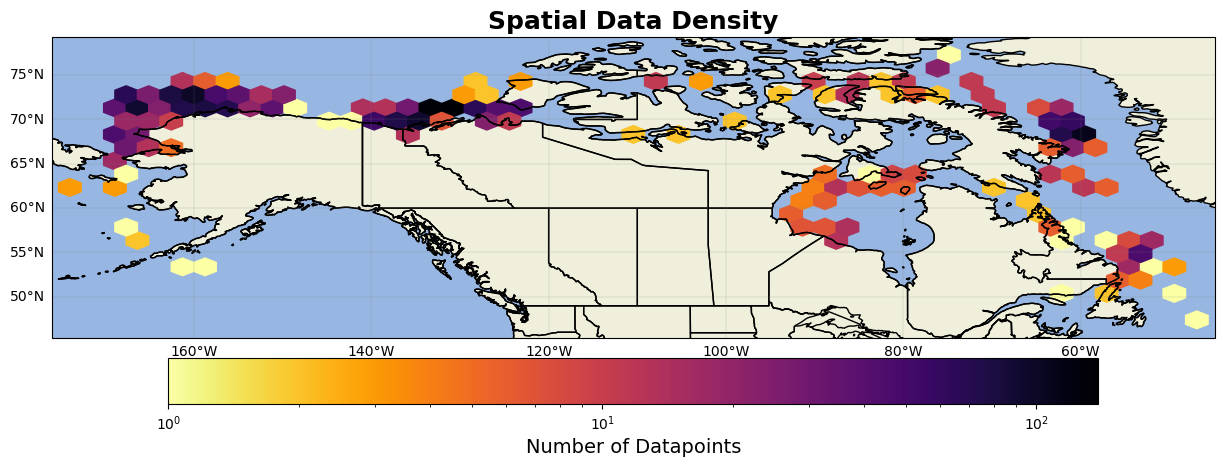

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(50,10), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()